# 비지도 학습 군집분석: 정답지가 없는 분석

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [146]:
data = pd.read_csv("./data/shopping-data.csv")
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [147]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [148]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<Axes: >

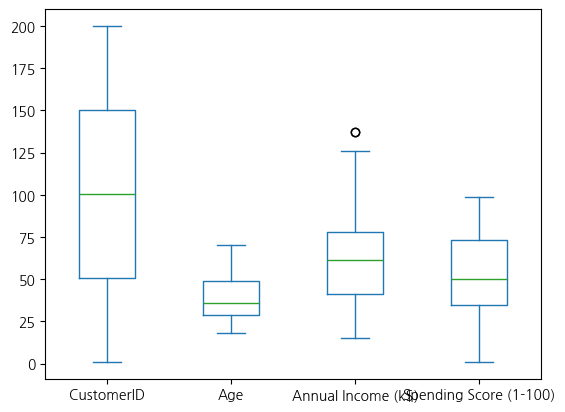

In [149]:
data.plot(kind='box')

# 군집분석(계층적 군집, 비계층적 군집)
* 계층적 군집
  * 비지도학습
  * 데이터가 적을 때 사용
  * 거리 계산 지표: 유클리드, 맨하탄, 코사인 유사도
* 계층적 군집 5가지
  * 단일연결법(single linkage), 최단연결법: 군집과 군집 사이에서 가장 가까운 데이터를 기준으로 묶음
  * 완전연결법(complite linkage), 최장연결법: 군집과 군집 사이에서 가장 먼 데이터를 기준으로 묶음
  * 평균연결법(average linkage): 군집과 군집 사이의 모든 데이터의 평균 데이터로 계산(이상치에 덜 민감)
  * 중심연결법(centroid linkage): 군집과 중심점 사이의 거리를 거리로 측정한 방법, 계산이 빠름
  * 와드연결법(ward linkage): 군집내 오차가 최소가 되는 데이터로 계산, 군집내 분산이 최소, 조밀한 군집
* 계층적 군집의 시각화는 덴드로그램으로 한다.

In [150]:
import scipy.cluster.hierarchy as shc

In [151]:
data = pd.get_dummies(data, drop_first=True)
data

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False
...,...,...,...,...,...
195,196,35,120,79,False
196,197,45,126,28,False
197,198,32,126,74,True
198,199,32,137,18,True


In [152]:
data2 = data.copy()

In [153]:
data = data.drop('CustomerID', axis=1)
data

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False
...,...,...,...,...
195,35,120,79,False
196,45,126,28,False
197,32,126,74,True
198,32,137,18,True


# 군집분석 거리가 중요하므로 스케일링 필수

In [154]:
from sklearn.preprocessing import StandardScaler

In [155]:
ss = StandardScaler()
scaled_df = ss.fit_transform(data)
scaled_df = pd.DataFrame(scaled_df, index=data.index, columns=data.columns)
scaled_df

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405
...,...,...,...,...
195,-0.276302,2.268791,1.118061,-0.886405
196,0.441365,2.497807,-0.861839,-0.886405
197,-0.491602,2.497807,0.923953,1.128152
198,-0.491602,2.917671,-1.250054,1.128152


* 싱글링키지(single linkage) 최단연결법

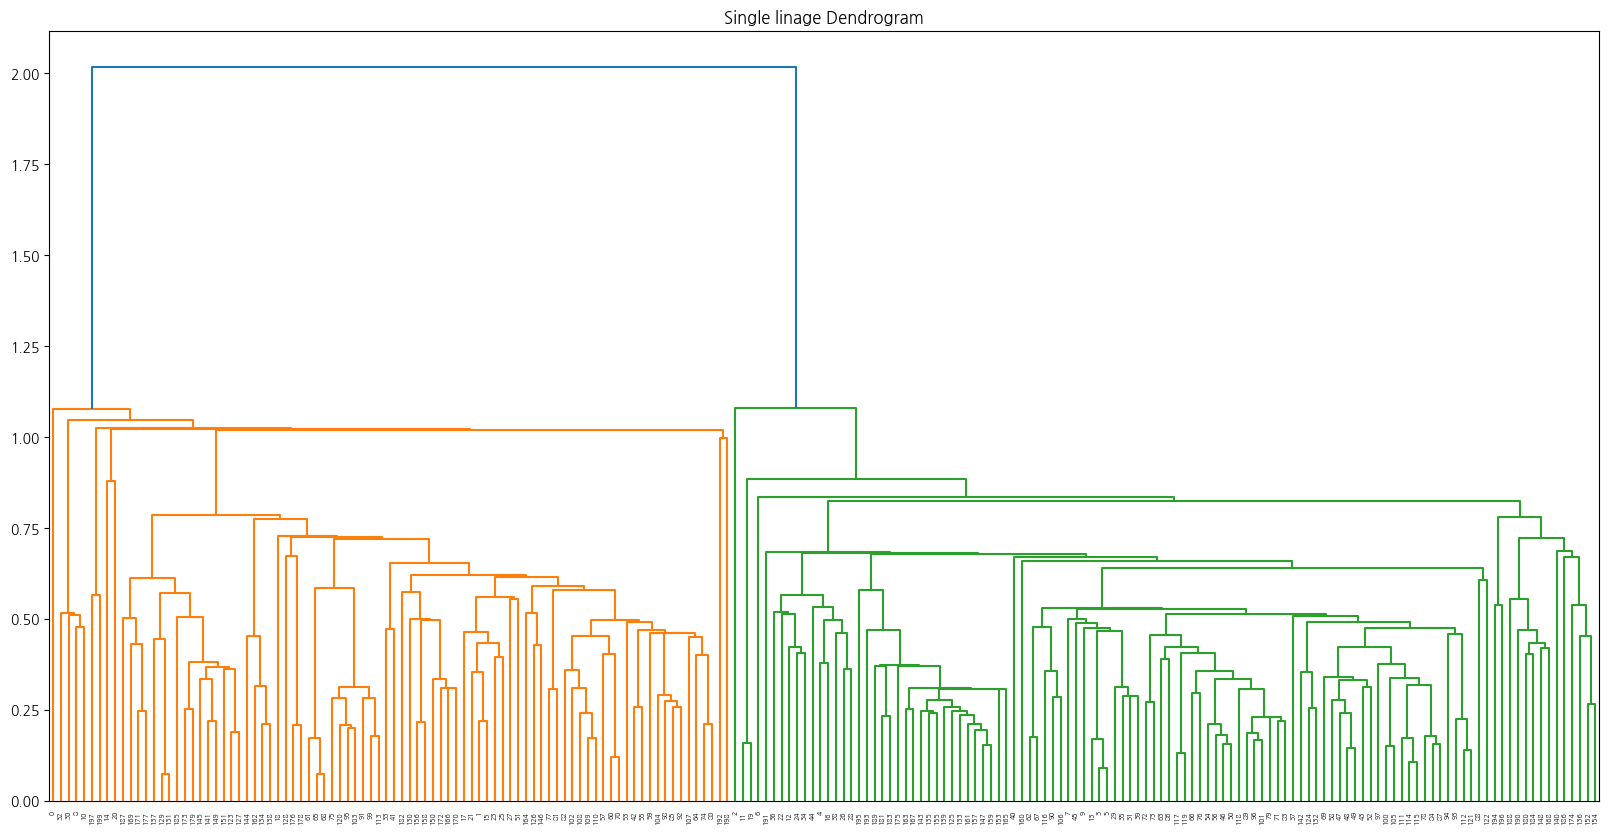

In [156]:
plt.figure(figsize=(20, 10))
plt.title('Single linage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='single'))
plt.show()

* 완전연결법(complete linkage) 최장연결법

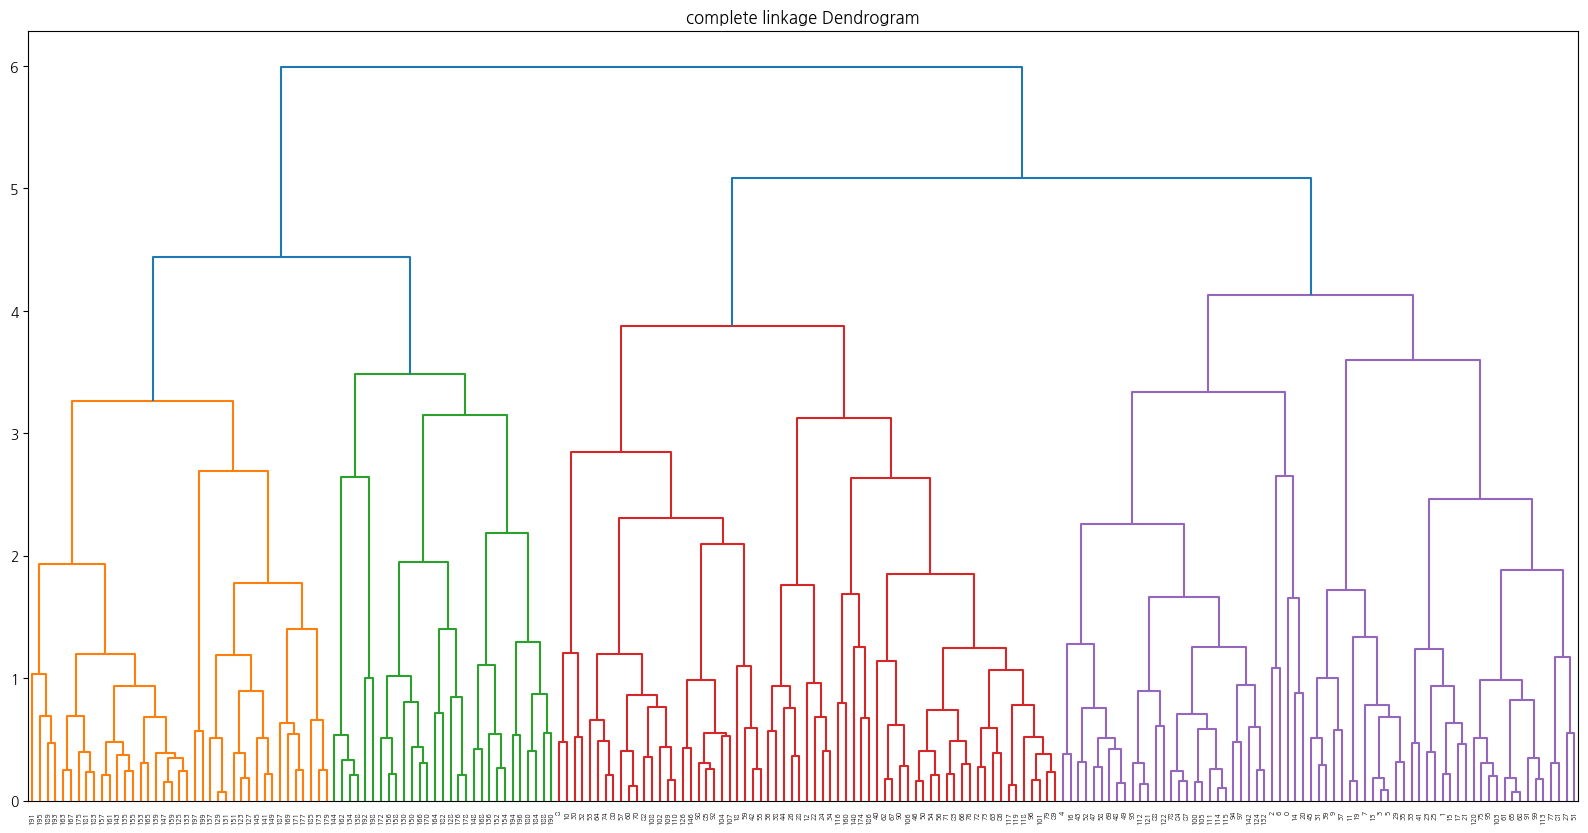

In [157]:
plt.figure(figsize=(20, 10))
plt.title('complete linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='complete'))
plt.show()

* 평균 연결법(average linkage)

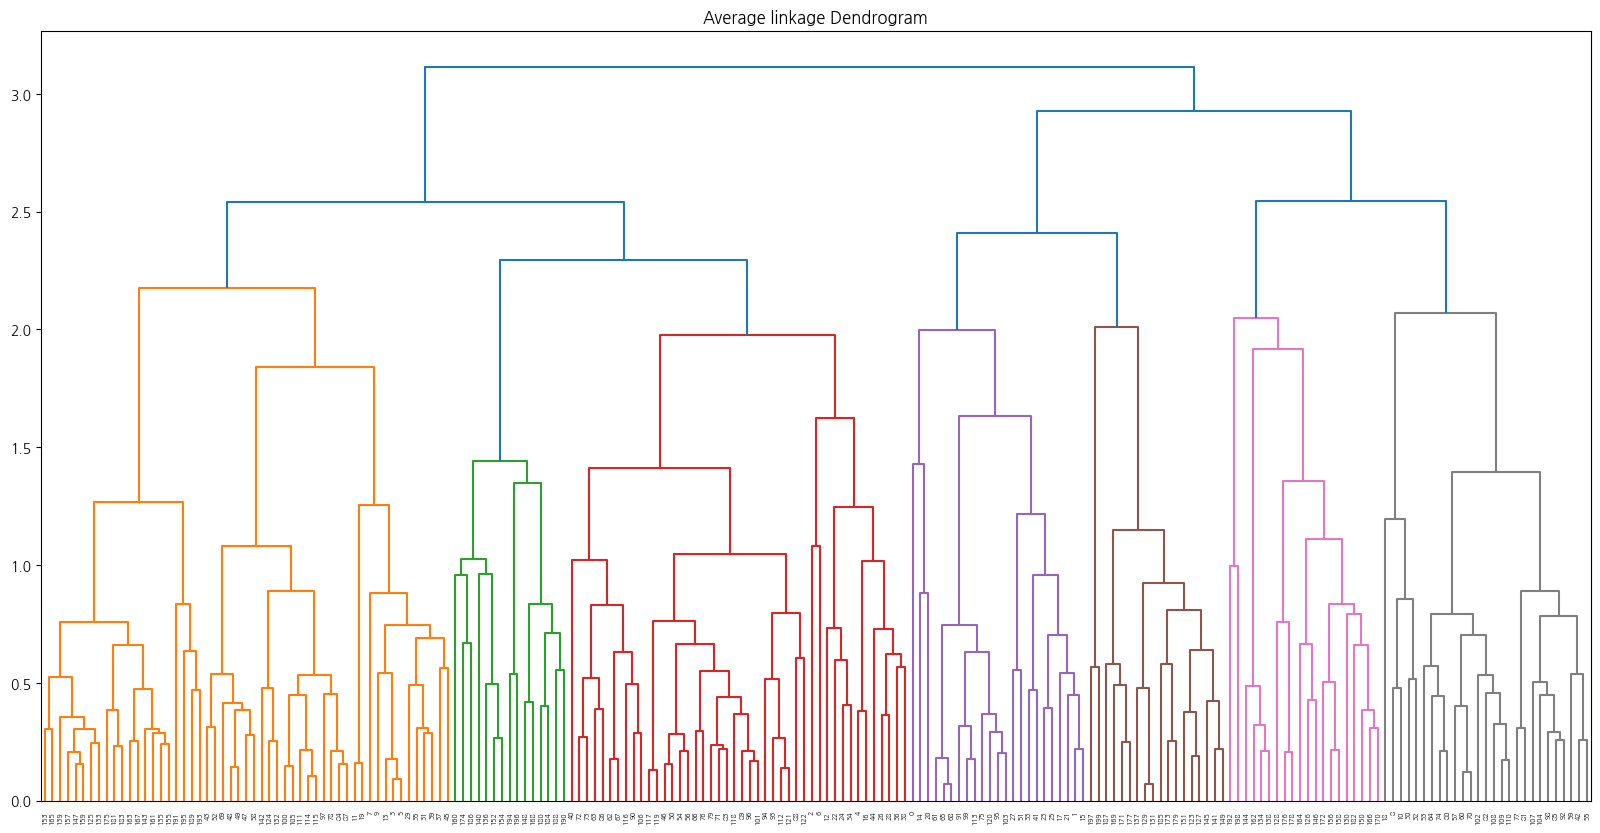

In [158]:
plt.figure(figsize=(20, 10))
plt.title('Average linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='average'))
plt.show()

* 중심연결법(centroid linkage)

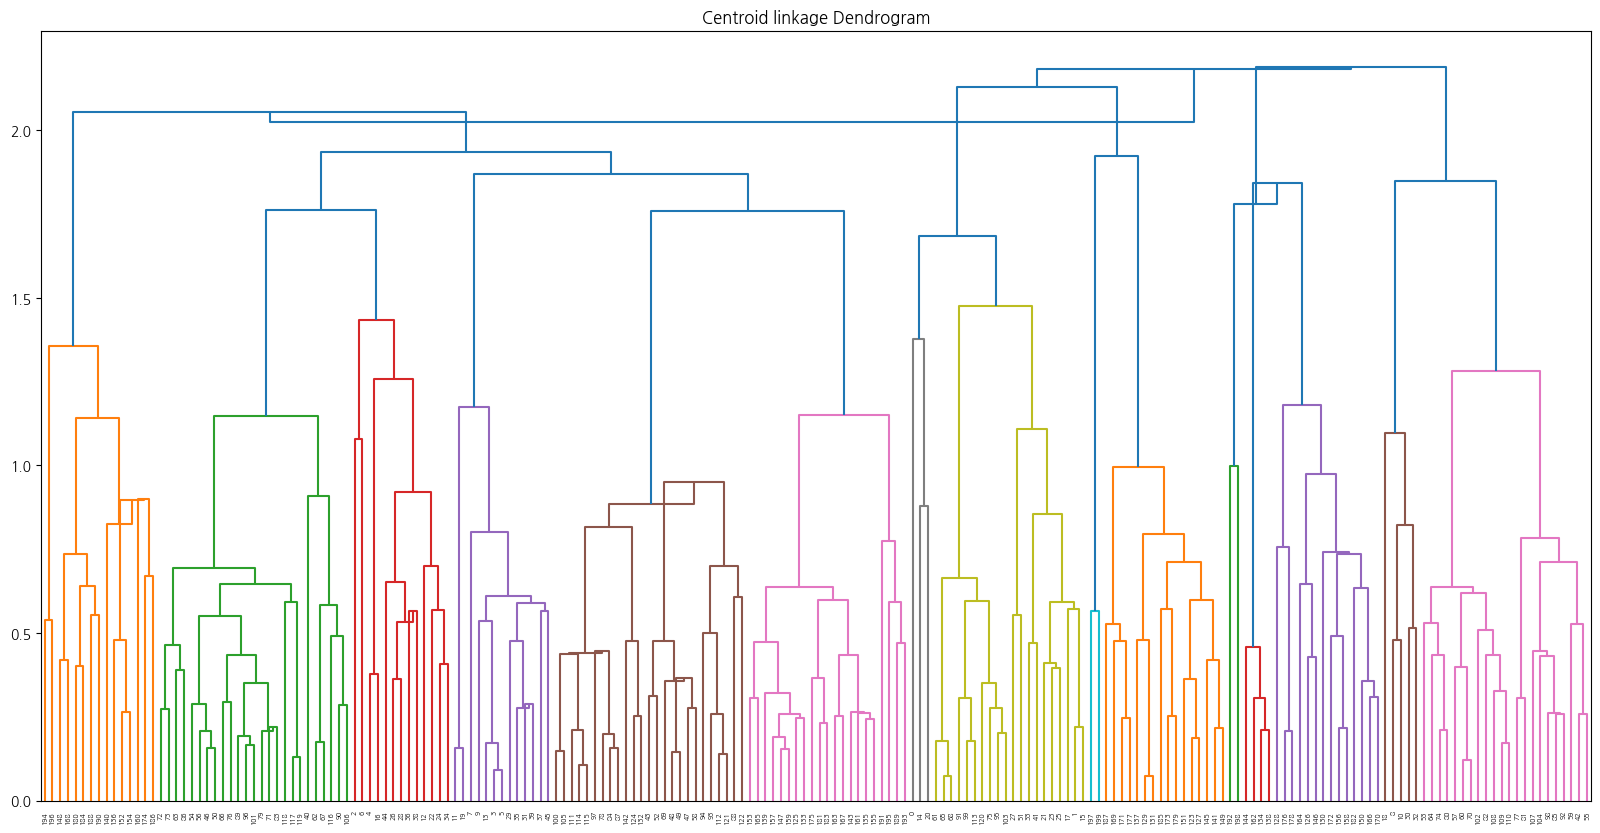

In [159]:
plt.figure(figsize=(20, 10))
plt.title('Centroid linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='centroid'))
plt.show()

* 와드연결법(ward linkage) - 군집내 분산 최소화

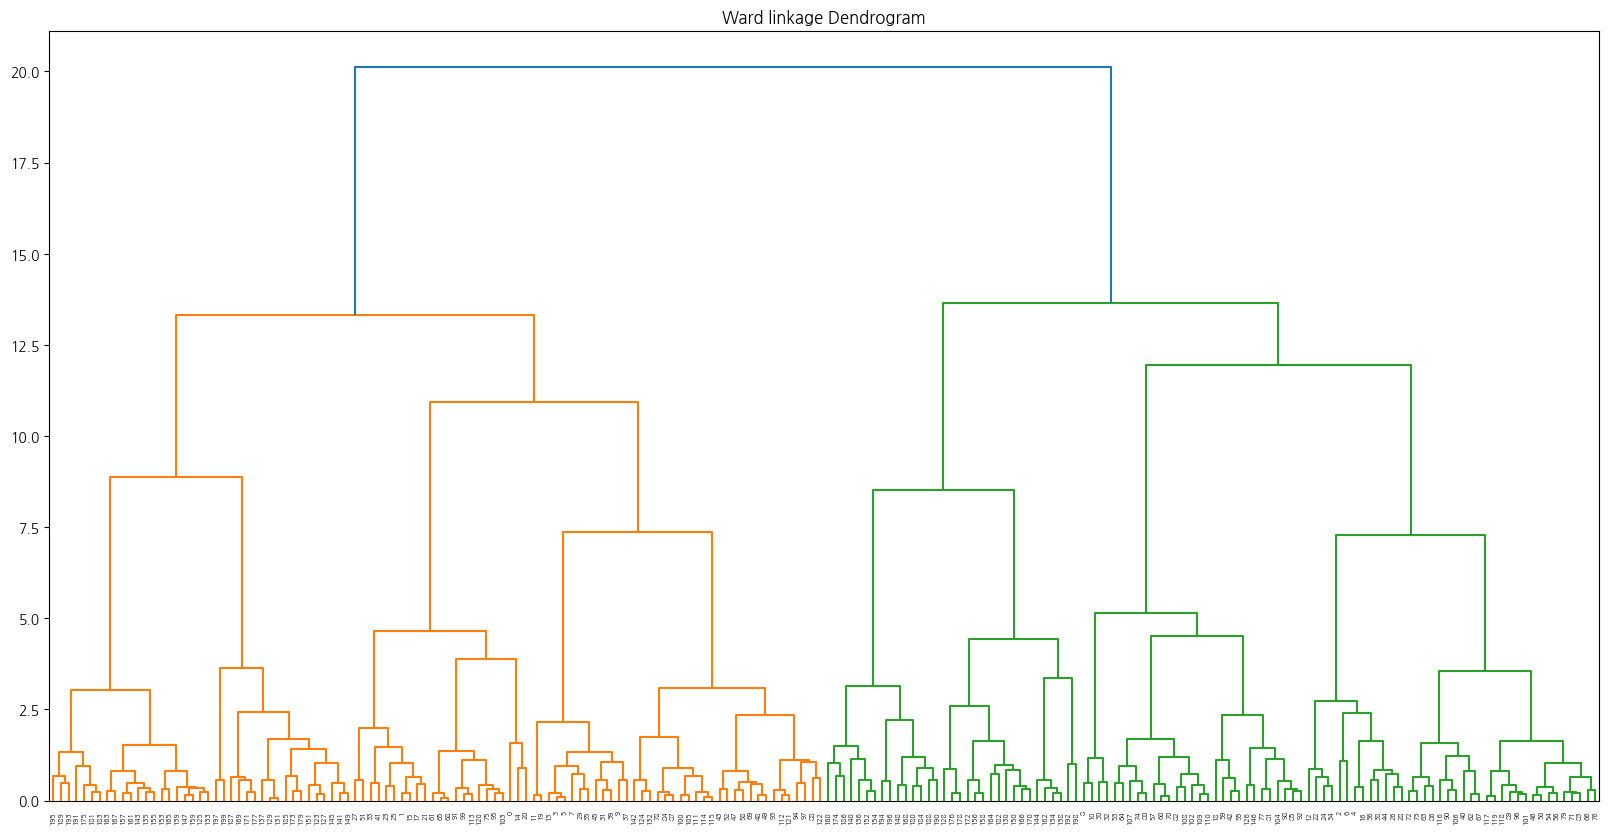

In [160]:
plt.figure(figsize=(20, 10))
plt.title('Ward linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='ward'))
plt.show()

# scikit-learn을 이용한 계층군집

In [161]:
from sklearn.cluster import AgglomerativeClustering

In [162]:
single = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='single')
result = single.fit_predict(scaled_df)
result

array([0, 0, 1, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0,
       2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0, 0,
       2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0,
       0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0,
       2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2,
       2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2,
       0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0,
       0, 0])

In [163]:
data2['single'] = result
data2

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single
0,1,19,15,39,True,0
1,2,21,15,81,True,0
2,3,20,16,6,False,1
3,4,23,16,77,False,2
4,5,31,17,40,False,2
...,...,...,...,...,...,...
195,196,35,120,79,False,2
196,197,45,126,28,False,2
197,198,32,126,74,True,0
198,199,32,137,18,True,0


In [164]:
for linkage in ['complete', 'average', 'ward']:
    single = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage=linkage)
    result = single.fit_predict(scaled_df)
    data2[linkage] = result
    display(data2)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete
0,1,19,15,39,True,0,1
1,2,21,15,81,True,0,1
2,3,20,16,6,False,1,1
3,4,23,16,77,False,2,1
4,5,31,17,40,False,2,1
...,...,...,...,...,...,...,...
195,196,35,120,79,False,2,0
196,197,45,126,28,False,2,0
197,198,32,126,74,True,0,0
198,199,32,137,18,True,0,0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete,average
0,1,19,15,39,True,0,1,2
1,2,21,15,81,True,0,1,2
2,3,20,16,6,False,1,1,1
3,4,23,16,77,False,2,1,1
4,5,31,17,40,False,2,1,1
...,...,...,...,...,...,...,...,...
195,196,35,120,79,False,2,0,1
196,197,45,126,28,False,2,0,1
197,198,32,126,74,True,0,0,2
198,199,32,137,18,True,0,0,0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete,average,ward
0,1,19,15,39,True,0,1,2,0
1,2,21,15,81,True,0,1,2,0
2,3,20,16,6,False,1,1,1,1
3,4,23,16,77,False,2,1,1,0
4,5,31,17,40,False,2,1,1,1
...,...,...,...,...,...,...,...,...,...
195,196,35,120,79,False,2,0,1,0
196,197,45,126,28,False,2,0,1,2
197,198,32,126,74,True,0,0,2,0
198,199,32,137,18,True,0,0,0,2


In [165]:
data2

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete,average,ward
0,1,19,15,39,True,0,1,2,0
1,2,21,15,81,True,0,1,2,0
2,3,20,16,6,False,1,1,1,1
3,4,23,16,77,False,2,1,1,0
4,5,31,17,40,False,2,1,1,1
...,...,...,...,...,...,...,...,...,...
195,196,35,120,79,False,2,0,1,0
196,197,45,126,28,False,2,0,1,2
197,198,32,126,74,True,0,0,2,0
198,199,32,137,18,True,0,0,0,2


In [166]:
data2[data2['single'] == 0].describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),single,complete,average,ward
count,88.000000,88.000000,88.000000,88.000000,88.0,88.000000,88.000000,88.000000
mean,104.238636,39.806818,62.227273,48.511364,0.0,0.897727,0.931818,0.738636
std,57.483830,15.514812,26.638373,27.896770,0.0,0.844724,1.003390,0.780426
min,1.000000,18.000000,15.000000,1.000000,0.0,0.000000,0.000000,0.000000
25%,59.500000,27.750000,45.500000,24.500000,0.0,0.000000,0.000000,0.000000
50%,106.500000,37.000000,62.500000,50.000000,0.0,1.000000,0.000000,1.000000
75%,151.250000,50.500000,78.000000,70.000000,0.0,2.000000,2.000000,1.000000
max,200.000000,70.000000,137.000000,97.000000,0.0,2.000000,2.000000,2.000000


In [167]:
data2[data2['single'] == 2].describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),single,complete,average,ward
count,111.000000,111.000000,111.000000,111.000000,111.0,111.000000,111.0,111.000000
mean,98.414414,38.261261,59.639640,51.936937,2.0,1.054054,1.0,0.603604
std,57.835891,12.582608,25.799504,23.828661,0.0,0.795874,0.0,0.717056
min,4.000000,18.000000,16.000000,5.000000,2.0,0.000000,1.0,0.000000
25%,47.500000,29.500000,40.000000,37.000000,2.0,0.000000,1.0,0.000000
50%,95.000000,35.000000,60.000000,50.000000,2.0,1.000000,1.0,0.000000
75%,148.500000,48.000000,77.500000,73.000000,2.0,2.000000,1.0,1.000000
max,197.000000,68.000000,126.000000,99.000000,2.0,2.000000,1.0,2.000000


In [168]:
data2[data2['average'] == 0].describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),single,complete,average,ward
count,47.000000,47.000000,47.000000,47.000000,47.0,47.000000,47.0,47.000000
mean,108.170213,49.765957,63.957447,29.978723,0.0,1.191489,0.0,1.382979
std,52.182922,13.997225,23.475202,19.664014,0.0,0.969946,0.0,0.491369
min,9.000000,19.000000,19.000000,1.000000,0.0,0.000000,0.0,1.000000
25%,68.000000,41.000000,48.500000,11.500000,0.0,0.000000,0.0,1.000000
50%,108.000000,49.000000,63.000000,35.000000,0.0,2.000000,0.0,1.000000
75%,154.000000,59.500000,78.000000,47.500000,0.0,2.000000,0.0,2.000000
max,199.000000,70.000000,137.000000,60.000000,0.0,2.000000,0.0,2.000000


In [169]:
data2[data2['average'] == 1].describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),single,complete,average,ward
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.0,112.000000
mean,97.562500,38.098214,59.250000,51.526786,1.991071,1.053571,1.0,0.607143
std,58.276412,12.644095,26.011952,24.114950,0.094491,0.792297,0.0,0.714800
min,3.000000,18.000000,16.000000,5.000000,1.000000,0.000000,1.0,0.000000
25%,46.750000,29.000000,39.750000,35.000000,2.000000,0.000000,1.0,0.000000
50%,94.500000,35.000000,60.000000,50.000000,2.000000,1.000000,1.0,0.000000
75%,148.250000,47.500000,77.250000,73.000000,2.000000,2.000000,1.0,1.000000
max,197.000000,68.000000,126.000000,99.000000,2.000000,2.000000,1.0,2.000000


In [170]:
data2[data2['average'] == 2].describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),single,complete,average,ward
count,41.000000,41.000000,41.000000,41.000000,41.0,41.000000,41.0,41.0
mean,99.731707,28.390244,60.243902,69.756098,0.0,0.560976,2.0,0.0
std,63.376267,6.934977,30.034797,19.539422,0.0,0.502433,0.0,0.0
min,1.000000,18.000000,15.000000,13.000000,0.0,0.000000,2.0,0.0
25%,34.000000,22.000000,33.000000,56.000000,0.0,0.000000,2.0,0.0
50%,104.000000,28.000000,62.000000,73.000000,0.0,1.000000,2.0,0.0
75%,150.000000,34.000000,78.000000,88.000000,0.0,1.000000,2.0,0.0
max,200.000000,40.000000,137.000000,97.000000,0.0,1.000000,2.0,0.0


# 비계층적 군집 - 데이터가 수가 많을 때 사용
* k-means(k 평균 군집): 거리를 기반으로 군집을 형성, 이상치에 민감함
* StandardScaler 사용, 데이터에 이상치가 있으면 RobustScaler 사용
* 이상치가 많은 경우 평균이 아닌 중앙값을 이용해서 군집 형성
* k 의 개수 구하는 것이 튜닝

In [171]:
data = pd.read_csv("./data/고객이탈예측.csv", encoding="cp949")
data

,회원ID,성별,고연령,배우자,피부양자,가입기간,전화서비스,2회선이상,인터넷서비스,온라인보안,...,기기보호서비스,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,월요금,합산요금,이탈여부
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [172]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   회원ID        7043 non-null   str    
 1   성별          7043 non-null   str    
 2   고연령         7043 non-null   int64  
 3   배우자         7043 non-null   str    
 4   피부양자        7043 non-null   str    
 5   가입기간        7043 non-null   int64  
 6   전화서비스       7043 non-null   str    
 7   2회선이상       7043 non-null   str    
 8   인터넷서비스      7043 non-null   str    
 9   온라인보안       7043 non-null   str    
 10  온라인백업       7043 non-null   str    
 11  기기보호서비스     7043 non-null   str    
 12  기술지원        7043 non-null   str    
 13  스트리밍TV      7043 non-null   str    
 14  스트리밍Movies  7043 non-null   str    
 15  약정옵션        7043 non-null   str    
 16  온라인고지서      7043 non-null   str    
 17  지불수단        7043 non-null   str    
 18  월요금         7043 non-null   float64
 19  합산요금        7043 non-null   str    
 2

In [173]:
data['합산요금'].astype(float)

ValueError: could not convert string to float: ' '

In [174]:
hap_price = data.loc[data['합산요금'] == ' ', '월요금'].astype(str)

In [175]:
hap_price

488     52.55
753     20.25
936     80.85
1082    25.75
1340    56.05
3331    19.85
3826    25.35
4380     20.0
5218     19.7
6670    73.35
6754     61.9
Name: 월요금, dtype: str

In [176]:
data.loc[data['합산요금'] == ' ', '합산요금'] = hap_price

In [177]:
data.loc[488]

회원ID                         4472-LVYGI
성별                               Female
고연령                                   0
배우자                                 Yes
피부양자                                Yes
가입기간                                  0
전화서비스                                No
2회선이상                  No phone service
인터넷서비스                              DSL
온라인보안                               Yes
온라인백업                                No
기기보호서비스                             Yes
기술지원                                Yes
스트리밍TV                              Yes
스트리밍Movies                           No
약정옵션                           Two year
온라인고지서                              Yes
지불수단          Bank transfer (automatic)
월요금                               52.55
합산요금                              52.55
이탈여부                                 No
Name: 488, dtype: object

In [178]:
data.loc[data['합산요금'] == ' ']

,회원ID,성별,고연령,배우자,피부양자,가입기간,전화서비스,2회선이상,인터넷서비스,온라인보안,...,기기보호서비스,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,월요금,합산요금,이탈여부


In [179]:
data['합산요금'] = data['합산요금'].astype(float)

In [180]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   회원ID        7043 non-null   str    
 1   성별          7043 non-null   str    
 2   고연령         7043 non-null   int64  
 3   배우자         7043 non-null   str    
 4   피부양자        7043 non-null   str    
 5   가입기간        7043 non-null   int64  
 6   전화서비스       7043 non-null   str    
 7   2회선이상       7043 non-null   str    
 8   인터넷서비스      7043 non-null   str    
 9   온라인보안       7043 non-null   str    
 10  온라인백업       7043 non-null   str    
 11  기기보호서비스     7043 non-null   str    
 12  기술지원        7043 non-null   str    
 13  스트리밍TV      7043 non-null   str    
 14  스트리밍Movies  7043 non-null   str    
 15  약정옵션        7043 non-null   str    
 16  온라인고지서      7043 non-null   str    
 17  지불수단        7043 non-null   str    
 18  월요금         7043 non-null   float64
 19  합산요금        7043 non-null   float64
 2

In [181]:
data['가입기간'].value_counts()

가입기간
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

<Axes: >

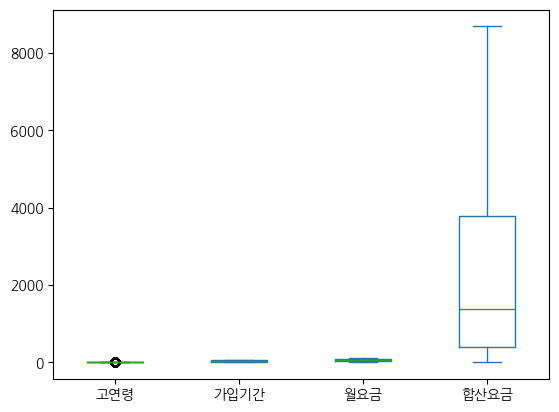

In [182]:
data.plot(kind='box')

* 범주형 변수를 one-hot encoding

In [184]:
data2 = data.drop('회원ID', axis=1)
data2

,성별,고연령,배우자,피부양자,가입기간,전화서비스,2회선이상,인터넷서비스,온라인보안,온라인백업,기기보호서비스,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,월요금,합산요금,이탈여부
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [185]:
data2 = pd.get_dummies(data2, drop_first=True)
data2

,고연령,가입기간,월요금,합산요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,...,스트리밍TV_Yes,스트리밍Movies_No internet service,스트리밍Movies_Yes,약정옵션_One year,약정옵션_Two year,온라인고지서_Yes,지불수단_Credit card (automatic),지불수단_Electronic check,지불수단_Mailed check,이탈여부_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,False,True,True,False,True,False,False,True,False
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,False,True,True,False,True,True,False,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,True,False,True,False,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,True,False,False,True,True


* standard scaler를 이용해 스케일 맞추기

In [186]:
from sklearn.preprocessing import StandardScaler

In [187]:
ss = StandardScaler()
scaled_df = ss.fit_transform(data2)
scaled_df = pd.DataFrame(scaled_df, index=data2.index, columns=data2.columns)
scaled_df

,고연령,가입기간,월요금,합산요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,...,스트리밍TV_Yes,스트리밍Movies_No internet service,스트리밍Movies_Yes,약정옵션_One year,약정옵션_Two year,온라인고지서_Yes,지불수단_Credit card (automatic),지불수단_Electronic check,지불수단_Mailed check,이탈여부_Yes
0,-0.439916,-1.277445,-1.160323,-0.992667,-1.009559,1.034530,-0.654012,-3.054010,3.054010,-0.854176,...,-0.790132,-0.525927,-0.796070,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807,-0.601023
1,-0.439916,0.066327,-0.259629,-0.172198,0.990532,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.790132,-0.525927,-0.796070,1.944582,-0.562975,-1.205113,-0.525047,-0.711026,1.835513,-0.601023
2,-0.439916,-1.236724,-0.362660,-0.958122,0.990532,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.790132,-0.525927,-0.796070,-0.514249,-0.562975,0.829798,-0.525047,-0.711026,1.835513,1.663829
3,-0.439916,0.514251,-0.746535,-0.193706,0.990532,-0.966622,-0.654012,-3.054010,3.054010,-0.854176,...,-0.790132,-0.525927,-0.796070,1.944582,-0.562975,-1.205113,-0.525047,-0.711026,-0.544807,-0.601023
4,-0.439916,-1.236724,0.197365,-0.938930,-1.009559,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.790132,-0.525927,-0.796070,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807,1.663829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,-0.439916,-0.340876,0.665992,-0.127637,0.990532,1.034530,1.529024,0.327438,-0.327438,1.170719,...,1.265612,-0.525927,1.256171,1.944582,-0.562975,0.829798,-0.525047,-0.711026,1.835513,-0.601023
7039,-0.439916,1.613701,1.277533,2.242641,-1.009559,1.034530,1.529024,0.327438,-0.327438,1.170719,...,1.265612,-0.525927,1.256171,1.944582,-0.562975,0.829798,1.904590,-0.711026,-0.544807,-0.601023
7040,-0.439916,-0.870241,-1.168632,-0.852985,-1.009559,1.034530,1.529024,-3.054010,3.054010,-0.854176,...,-0.790132,-0.525927,-0.796070,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807,-0.601023
7041,2.273159,-1.155283,0.320338,-0.870566,0.990532,1.034530,-0.654012,0.327438,-0.327438,1.170719,...,-0.790132,-0.525927,-0.796070,-0.514249,-0.562975,0.829798,-0.525047,-0.711026,1.835513,1.663829


# K-means로 군집 분석

In [188]:
from sklearn.cluster import KMeans

In [191]:
# KMeans의 기본 n_clusters=8
km = KMeans(random_state=42)
km.fit(scaled_df)
result = km.labels_
result

array([0, 4, 4, ..., 0, 7, 3], shape=(7043,), dtype=int32)

In [192]:
data2['cluster8'] = result
data2

,고연령,가입기간,월요금,합산요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,...,스트리밍Movies_No internet service,스트리밍Movies_Yes,약정옵션_One year,약정옵션_Two year,온라인고지서_Yes,지불수단_Credit card (automatic),지불수단_Electronic check,지불수단_Mailed check,이탈여부_Yes,cluster8
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,True,False,True,False,False,0
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,4
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,True,False,False,True,True,4
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,0
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,False,True,True,False,True,False,False,True,False,5
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,False,True,True,False,True,True,False,False,False,5
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,True,False,True,False,False,0
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,True,False,False,True,True,7


In [194]:
data2['cluster8'].value_counts()

cluster8
7    1200
4    1064
2     903
1     892
3     872
5     796
0     682
6     634
Name: count, dtype: int64

In [196]:
data2[data2['cluster8'] == 7]['이탈여부_Yes'].value_counts()

이탈여부_Yes
True     898
False    302
Name: count, dtype: int64

In [198]:
data2[data2['cluster8'] == 7].describe(include='all')

,고연령,가입기간,월요금,합산요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,...,스트리밍Movies_No internet service,스트리밍Movies_Yes,약정옵션_One year,약정옵션_Two year,온라인고지서_Yes,지불수단_Credit card (automatic),지불수단_Electronic check,지불수단_Mailed check,이탈여부_Yes,cluster8
count,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200,1200,1200,1200,1200,...,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200.0
unique,NaN,NaN,NaN,NaN,2,2,2,1,1,2,...,1,2,2,2,2,2,2,2,2,NaN
top,NaN,NaN,NaN,NaN,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,NaN
freq,NaN,NaN,NaN,NaN,640,928,1055,1200,1200,718,...,1200,824,1192,1198,945,1138,948,1122,898,NaN
mean,0.249167,9.595833,77.868542,757.949750,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
std,0.432711,10.024864,11.772280,796.248393,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
min,0.000000,1.000000,42.900000,42.900000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
25%,0.000000,2.000000,71.000000,144.112500,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
50%,0.000000,6.000000,79.050000,477.625000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
75%,0.000000,14.000000,85.450000,1112.675000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0


In [199]:
data2[data2['cluster8'] == 4]['이탈여부_Yes'].value_counts()

이탈여부_Yes
False    908
True     156
Name: count, dtype: int64

In [200]:
data2[data2['cluster8'] == 4].describe(include='all')

,고연령,가입기간,월요금,합산요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,...,스트리밍Movies_No internet service,스트리밍Movies_Yes,약정옵션_One year,약정옵션_Two year,온라인고지서_Yes,지불수단_Credit card (automatic),지불수단_Electronic check,지불수단_Mailed check,이탈여부_Yes,cluster8
count,1064.000000,1064.000000,1064.000000,1064.000000,1064,1064,1064,1064,1064,1064,...,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064.0
unique,NaN,NaN,NaN,NaN,2,2,2,1,1,2,...,1,2,2,2,2,2,2,2,2,NaN
top,NaN,NaN,NaN,NaN,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,NaN
freq,NaN,NaN,NaN,NaN,548,699,769,1064,1064,811,...,1064,895,914,1022,565,850,872,622,908,NaN
mean,0.062970,18.122180,60.500987,1128.369502,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
std,0.243023,15.712555,12.067968,1011.062861,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
min,0.000000,0.000000,43.450000,43.800000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
25%,0.000000,4.000000,50.450000,250.062500,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
50%,0.000000,14.000000,57.050000,866.425000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
75%,0.000000,27.250000,69.412500,1794.950000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0


# 군집의 최적 개수 정하기
* elbow method
* 실루엣 지수
* 군집분석 응집도 (요소들이 얼마나 모여있는지 판단하는 지표)
  * 응집도가 높다 == 분산이 작다
  * 응집도가 낮다 == 분산이 크다
  * inertia_ 값이 작을 수록 군집이 잘 형성됨
* elbow method: inertia_(응집도)를 출력하고 시각화 한 뒤 응집도의 감소폭이 급격한 변화가 시작되는 지즘을 최적 군집의 수로 채택  


In [201]:
print(km.inertia_)

100835.63093699006


# n_clusters를 1-20까지 변경하면서 inertia_출력 후 비교

In [202]:
inertia = []
for i in range(1, 21):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(scaled_df)
    inertia.append(km.inertia_)
inertia

[218332.9999999999,
 152479.05599373794,
 135638.58526372543,
 118049.58955068831,
 111917.47124326258,
 107077.31394401994,
 104313.83505460553,
 100835.63093699004,
 98707.88612842455,
 96791.35126700957,
 94818.94918967708,
 93377.42379563536,
 91819.52450297751,
 90440.10521805832,
 89030.11191959868,
 87958.18275215349,
 87544.95178231725,
 86602.96112714455,
 85915.7831604711,
 84283.81241543827]

In [203]:
import seaborn as sns

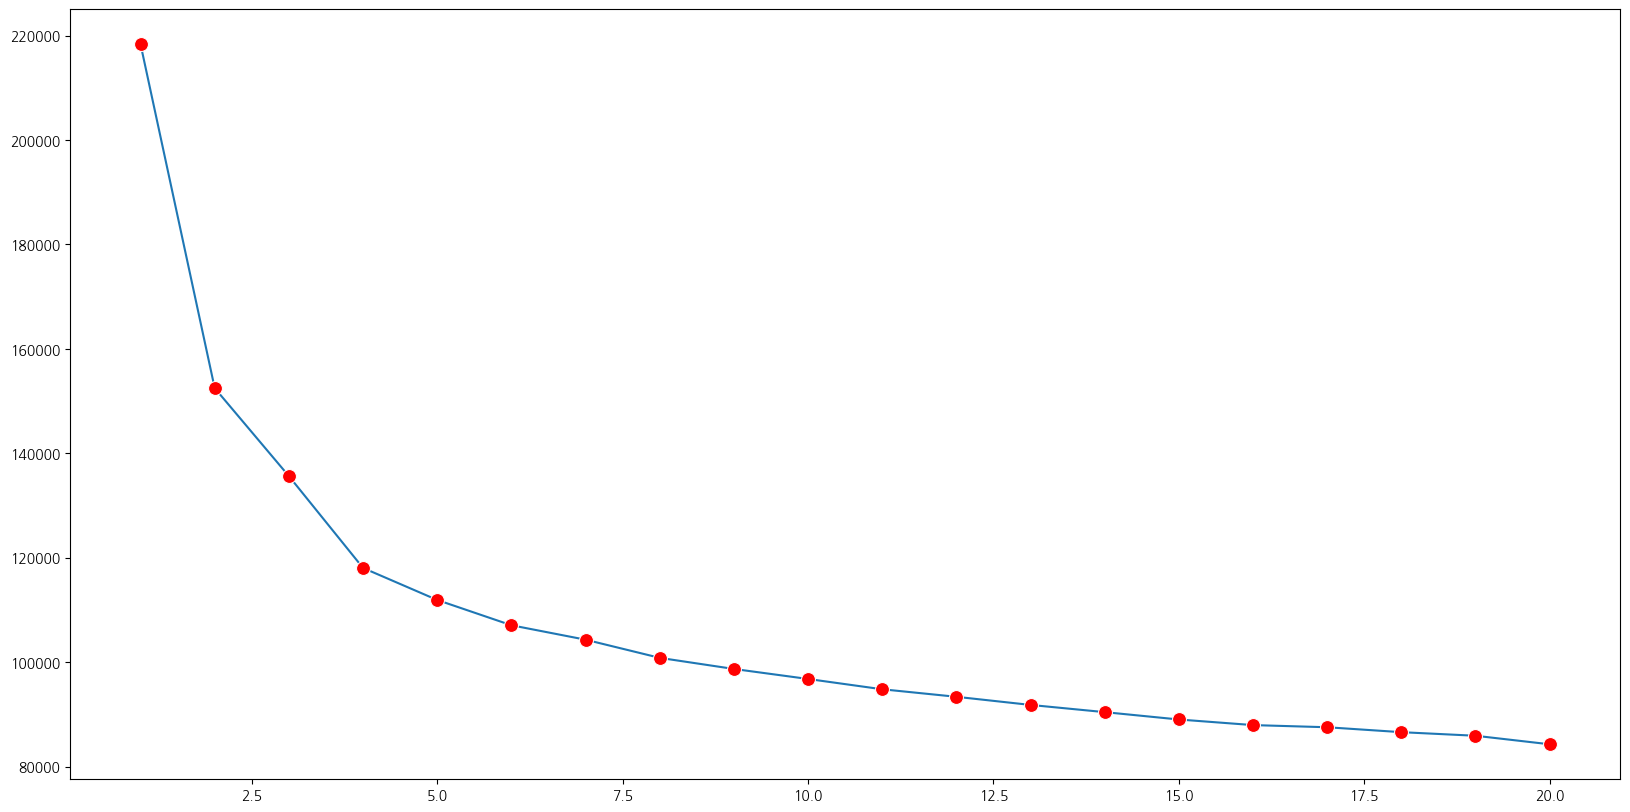

In [204]:
plt.figure(figsize=(20,10))
sns.lineplot(x=range(1,21), y=inertia, marker='o', markersize=10, markerfacecolor='red')
plt.show()

In [207]:
# KMeans의 기본 n_clusters=8
km = KMeans(n_clusters=4, random_state=42)
km.fit(scaled_df)
result = km.labels_
result

array([0, 3, 3, ..., 0, 3, 2], shape=(7043,), dtype=int32)

In [208]:
data2['clusters4'] = result

In [209]:
data2

,고연령,가입기간,월요금,합산요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,...,스트리밍Movies_Yes,약정옵션_One year,약정옵션_Two year,온라인고지서_Yes,지불수단_Credit card (automatic),지불수단_Electronic check,지불수단_Mailed check,이탈여부_Yes,cluster8,clusters4
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,True,False,True,False,False,0,0
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,True,False,False,False,False,True,False,4,3
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,True,False,False,True,True,4,3
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,0,0
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,True,False,True,False,True,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,True,False,True,False,False,True,False,5,2
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,True,False,True,True,False,False,False,5,2
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,True,False,True,False,False,0,0
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,True,False,False,True,True,7,3


In [210]:
data2['clusters4'].value_counts()

clusters4
3    2721
2    2114
1    1526
0     682
Name: count, dtype: int64

In [212]:
data2[data2['clusters4'] == 3]['이탈여부_Yes'].value_counts()

이탈여부_Yes
False    1393
True     1328
Name: count, dtype: int64

In [213]:
data2[data2['clusters4'] == 3].describe()

,고연령,가입기간,월요금,합산요금,cluster8,clusters4
count,2721.000000,2721.000000,2721.000000,2721.000000,2721.000000,2721.0
mean,0.220507,15.499816,74.284730,1180.387174,4.980154,3.0
std,0.414665,14.200045,16.554106,1125.662769,1.939804,0.0
min,0.000000,0.000000,42.900000,42.900000,2.000000,3.0
25%,0.000000,3.000000,59.900000,237.950000,4.000000,3.0
50%,0.000000,11.000000,75.350000,831.750000,4.000000,3.0
75%,0.000000,24.000000,86.550000,1836.250000,7.000000,3.0
max,1.000000,68.000000,112.950000,5617.750000,7.000000,3.0


In [214]:
data2[data2['clusters4'] == 2]['이탈여부_Yes'].value_counts()

이탈여부_Yes
False    1856
True      258
Name: count, dtype: int64

In [215]:
data2[data2['clusters4'] == 2].describe()

,고연령,가입기간,월요금,합산요금,cluster8,clusters4
count,2114.000000,2114.000000,2114.000000,2114.000000,2114.000000,2114.0
mean,0.182592,55.607852,91.370624,5115.005416,3.551088,2.0
std,0.386423,14.963845,15.788377,1733.295655,1.152167,0.0
min,0.000000,0.000000,49.400000,73.350000,2.000000,2.0
25%,0.000000,46.000000,79.712500,3872.412500,3.000000,2.0
50%,0.000000,59.000000,94.100000,5180.650000,3.000000,2.0
75%,0.000000,68.750000,104.650000,6413.050000,5.000000,2.0
max,1.000000,72.000000,118.750000,8684.800000,5.000000,2.0


# 실루엣 지수를 출력해서 최적 군집 개수 구하기
* 실루엣 지수를 구하기 위해서는 최소 2개 이상의 군집이 필요
* 실루엣 지수가 가장 높은 클러스터 개수가 최적 군집 개수(1에 가까울수록 좋음)

In [216]:
from sklearn.metrics import silhouette_score

In [217]:
sil_scores = []
for i in range(2, 21):
    km2 = KMeans(n_clusters=i, random_state=42)
    km2.fit(scaled_df)
    labels = km2.labels_
    sil_scores.append(silhouette_score(scaled_df, labels))
sil_scores

[0.3258652454879743,
 0.2804452435608257,
 0.23576171079139827,
 0.19947667968860916,
 0.1942023354192859,
 0.18517954103705075,
 0.12867767199413246,
 0.13004252885995762,
 0.12654262815135567,
 0.12268535473727389,
 0.11438673001870003,
 0.11548534988018003,
 0.11077706954479337,
 0.10892533061526664,
 0.10991577445040265,
 0.10684398657257481,
 0.1084841823266845,
 0.10812881050046247,
 0.10587131128596497]

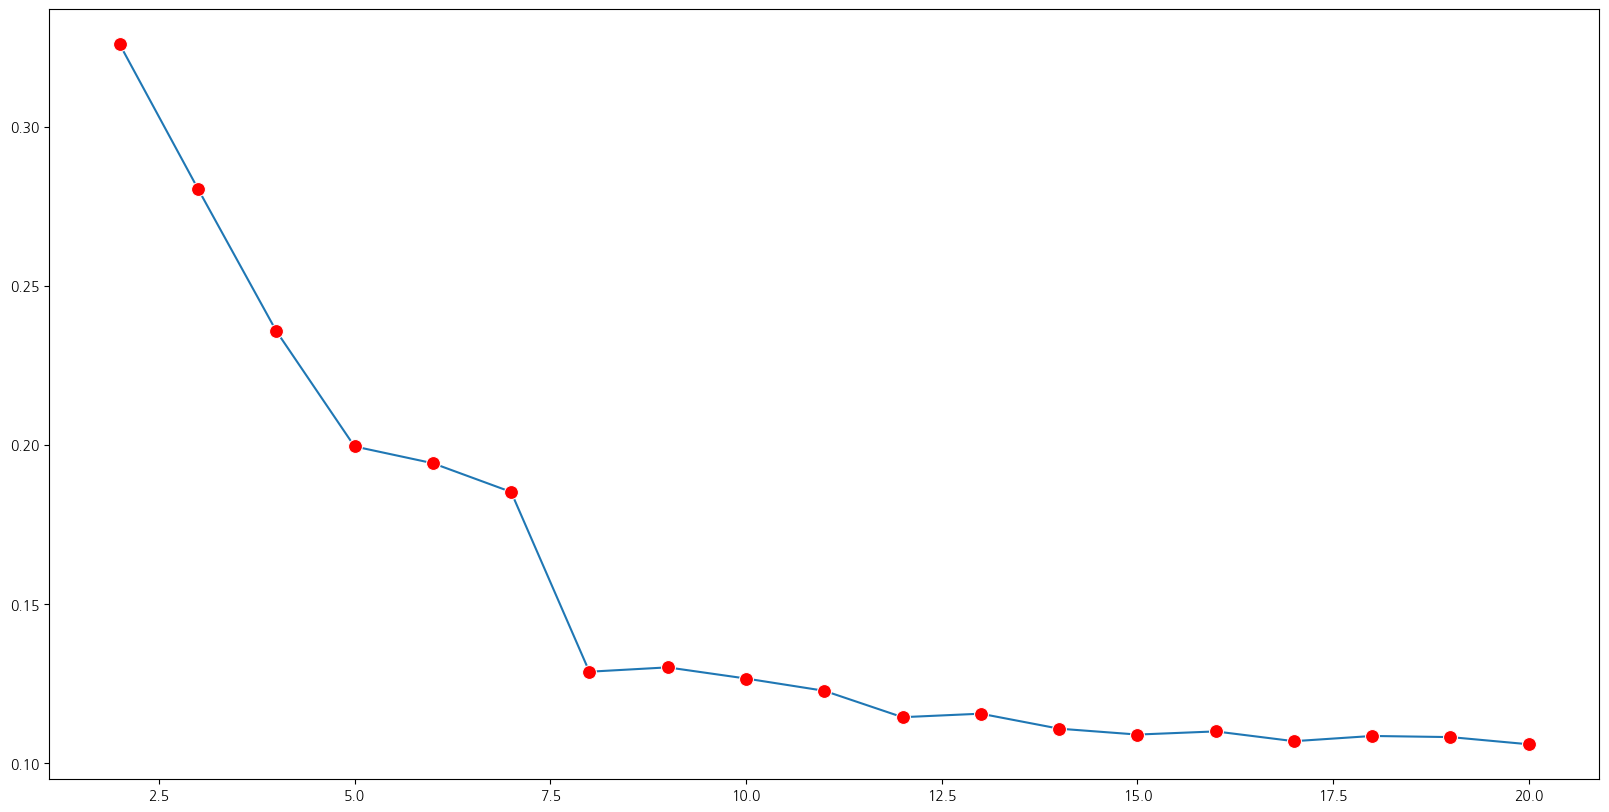

In [218]:
plt.figure(figsize=(20,10))
sns.lineplot(x=range(2, 21), y=sil_scores, marker='o', markersize=10, markerfacecolor='red')
plt.show()

In [219]:
# KMeans의 기본 n_clusters=8
km2 = KMeans(n_clusters=2, random_state=42)
km2.fit(scaled_df)
result = km2.labels_
result

array([0, 0, 0, ..., 0, 0, 0], shape=(7043,), dtype=int32)

In [220]:
data2['clusters2'] = result
data2

,고연령,가입기간,월요금,합산요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,...,약정옵션_One year,약정옵션_Two year,온라인고지서_Yes,지불수단_Credit card (automatic),지불수단_Electronic check,지불수단_Mailed check,이탈여부_Yes,cluster8,clusters4,clusters2
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,True,False,True,False,False,0,0,0
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,True,False,False,False,False,True,False,4,3,0
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,True,False,False,True,True,4,3,0
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,True,False,False,False,False,False,False,0,0,0
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,True,False,True,False,True,7,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,False,True,False,False,True,False,5,2,0
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,False,True,True,False,False,False,5,2,0
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,True,False,True,False,False,0,0,0
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,True,False,False,True,True,7,3,0


In [222]:
data2[data2['clusters2'] == 0].describe()

,고연령,가입기간,월요금,합산요금,cluster8,clusters4,clusters2
count,5517.000000,5517.000000,5517.000000,5517.000000,5517.000000,5517.000000,5517.0
mean,0.197571,32.875657,76.844254,2727.090538,3.816929,2.245967,0.0
std,0.398203,24.593647,21.924661,2355.978174,2.204514,0.962986,0.0
min,0.000000,0.000000,23.450000,23.450000,0.000000,0.000000,0.0
25%,0.000000,9.000000,59.950000,583.000000,2.000000,2.000000,0.0
50%,0.000000,30.000000,79.450000,2135.500000,4.000000,2.000000,0.0
75%,0.000000,56.000000,94.450000,4527.450000,5.000000,3.000000,0.0
max,1.000000,72.000000,118.750000,8684.800000,7.000000,3.000000,0.0


In [223]:
data2[data2['clusters2'] == 1].describe()

,고연령,가입기간,월요금,합산요금,cluster8,clusters4,clusters2
count,1526.000000,1526.000000,1526.000000,1526.000000,1526.000000,1526.0,1526.0
mean,0.034076,30.547182,21.079194,662.690564,3.077326,1.0,1.0
std,0.181484,24.356507,2.164221,555.527036,2.464818,0.0,0.0
min,0.000000,0.000000,18.250000,18.800000,1.000000,1.0,1.0
25%,0.000000,8.000000,19.700000,157.825000,1.000000,1.0,1.0
50%,0.000000,25.000000,20.150000,519.200000,1.000000,1.0,1.0
75%,0.000000,52.750000,20.900000,1108.650000,6.000000,1.0,1.0
max,1.000000,72.000000,26.900000,2006.950000,6.000000,1.0,1.0


In [224]:
data2[data2['clusters2'] == 0]['이탈여부_Yes'].value_counts()

이탈여부_Yes
False    3761
True     1756
Name: count, dtype: int64

In [225]:
data2[data2['clusters2'] == 1]['이탈여부_Yes'].value_counts()

이탈여부_Yes
False    1413
True      113
Name: count, dtype: int64